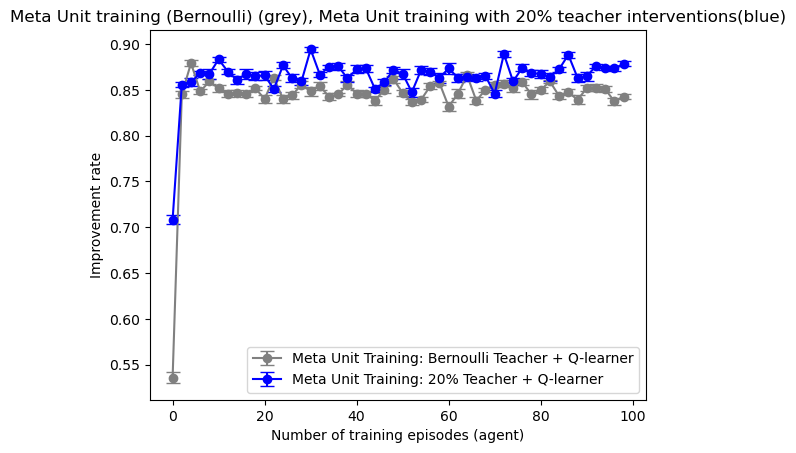

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Define global parameters
n_states = 10
n_actions = 4
epsilon = 0.1
alpha = 0.1
gamma = 0.95
planning_steps = 5
error_probability = 0.1
training_iterations = 100
smart_action_sequence = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1]
smart_action_sequence_learner = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1]

class DynaQAgent:
    def __init__(self, n_states, n_actions, epsilon=0.1, alpha=0.1, gamma=0.95, planning_steps=5):
        self.n_states = n_states
        self.n_actions = n_actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.planning_steps = planning_steps
        self.q_table = np.zeros((n_states, n_actions))
        self.model = {}
    
    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return np.random.choice(self.n_actions)
        else:
            return np.argmax(self.q_table[state])
    
    def update(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error
        self.model[(state, action)] = (reward, next_state)
        for _ in range(self.planning_steps):
            s, a = random.choice(list(self.model.keys()))
            r, s_next = self.model[(s, a)]
            best_next_a = np.argmax(self.q_table[s_next])
            td_target = r + self.gamma * self.q_table[s_next][best_next_a]
            td_error = td_target - self.q_table[s][a]
            self.q_table[s][a] += self.alpha * td_error
    
    def share_experience(self, peers, state):
        best_peer = max(peers, key=lambda p: p.q_table[state].max())
        for action in range(self.n_actions):
            self.q_table[state][action] = max(self.q_table[state][action], best_peer.q_table[state][action])
    
class SimulatedHumanLearner:
    def __init__(self, n_states, error_probability, smart_action_sequence_learner):
        self.state = 0
        self.n_states = n_states
        self.error_probability = error_probability
        self.smart_action_sequence_learner = smart_action_sequence_learner
    
    def perform_action(self, action):
        if random.uniform(0, 1) < self.error_probability:
            return 0  # Error made
        elif action == self.smart_action_sequence_learner[self.state]:
            self.state = min(self.n_states - 1, self.state + 1)
            return 1  # No error
        else:
            return 0
    
    def get_state(self):
        return self.state

class SimulatedTeacher:
    def __init__(self, smart_action_sequence):
        self.smart_action_sequence = smart_action_sequence
    
    def should_intervene(self, avg_reward):
        teacher_peak = 1 - avg_reward
        return np.random.binomial(1, teacher_peak) == 1
    
    def guide(self, human_learner):
        current_state = human_learner.get_state()
        if current_state < len(self.smart_action_sequence):
            action = self.smart_action_sequence[current_state]
            human_learner.state = min(human_learner.n_states - 1, human_learner.state + 1)
            return (current_state, action, 1, human_learner.get_state())
        else:
            return None

def simulate_learning(agent, human_learner, teacher, teacherF, peer_agents=[], episodes=100):
    rewards = []
    steps = 0
    while human_learner.get_state() < human_learner.n_states - 1 or steps < episodes:
        avg_reward = np.mean(rewards[-10:]) if len(rewards) >= 10 else 1
        if teacher.should_intervene(avg_reward) and teacherF == 1:
            result = teacher.guide(human_learner)
            if result:
                state, action, reward, next_state = result
        elif teacherF == 0.5 and random.uniform(0,1) < 0.2:
            result = teacher.guide(human_learner)
            if result:
                state, action, reward, next_state = result
            else:
                state = human_learner.get_state()
                action = agent.choose_action(state)
                reward = human_learner.perform_action(action)
                next_state = human_learner.get_state()
        else:
            state = human_learner.get_state()
            action = agent.choose_action(state)
            reward = human_learner.perform_action(action)
            next_state = human_learner.get_state()
        agent.update(state, action, reward, next_state)
        if peer_agents:
            agent.share_experience(peer_agents, state)
        rewards.append(reward)
        steps += 1
    return np.mean(rewards)

def eval(training_iterations):
    x, y = [], []
    agent_1 = DynaQAgent(n_states, n_actions, epsilon, alpha, gamma, planning_steps)
    agent_2 = DynaQAgent(n_states, n_actions, epsilon, alpha, gamma, planning_steps)
    teacher = SimulatedTeacher(smart_action_sequence)
    for _ in range(training_iterations):
        human_learner_1 = SimulatedHumanLearner(n_states, error_probability, smart_action_sequence_learner)
        x.append(simulate_learning(agent_1, human_learner_1, teacher, 1, peer_agents=[agent_2], episodes=30))
        human_learner_2 = SimulatedHumanLearner(n_states, error_probability, smart_action_sequence_learner)
        y.append(simulate_learning(agent_2, human_learner_2, teacher, 0.5, peer_agents=[agent_1], episodes=30))
    return x, y

def run(average_iterations):
    x, y = [], []
    for _ in range(average_iterations):
        meta, q = eval(training_iterations)
        x.append(meta)
        y.append(q)
    stacked_x = np.stack(x)
    stacked_y = np.stack(y)
    return np.mean(stacked_x, axis=0), np.var(stacked_x, axis=0), np.mean(stacked_y, axis=0), np.var(stacked_y, axis=0)

average_iterations = 40
mean_x, variance_x, mean_y, variance_y = run(average_iterations)

slice = 2
plt.errorbar(np.arange(training_iterations)[::slice], mean_x[::slice], yerr=variance_x[::slice], fmt='o-', capsize=5, label='Meta Unit Training: Bernoulli Teacher + Q-learner', color='grey')
plt.errorbar(np.arange(training_iterations)[::slice], mean_y[::slice], yerr=variance_y[::slice], fmt='o-', capsize=5, label='Meta Unit Training: 20% Teacher + Q-learner', color='blue')
plt.xlabel('Number of training episodes (agent)')
plt.ylabel('Improvement rate')
plt.title('Meta Unit training (Bernoulli) (grey), Meta Unit training with 20% teacher interventions(blue)')
plt.legend()
plt.show()
